In [13]:
# ============================================================
# CELL 1: Imports, reproducibility, and output directories
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )
except Exception:
    pass


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")

PROJECT_DIR = (
    KAGGLE_WORKING_DIR /
    "ATDL_Ternary_KD_QAT_Student"
)

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
PLOT_DIR = PROJECT_DIR / "plots"
LOG_DIR = PROJECT_DIR / "logs"
RESULT_DIR = PROJECT_DIR / "results"
CONFIG_DIR = PROJECT_DIR / "config"
SCRIPT_DIR = PROJECT_DIR / "scripts"
ENV_DIR = PROJECT_DIR / "environment"


for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    PLOT_DIR,
    LOG_DIR,
    RESULT_DIR,
    CONFIG_DIR,
    SCRIPT_DIR,
    ENV_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Environment info
# ------------------------------------------------------------

environment_info = {

    "python_version":
        sys.version,

    "platform":
        platform.platform(),

    "pytorch_version":
        torch.__version__,

    "torchvision_version":
        torchvision.__version__,

    "cuda_available":
        torch.cuda.is_available(),

    "cuda_version":
        torch.version.cuda,

    "device":
        str(DEVICE),

    "gpu_name":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        ),

    "seed":
        SEED,
}


with open(
    ENV_DIR / "environment.txt",
    "w"
) as f:

    for key, value in environment_info.items():
        f.write(
            f"{key}: {value}\n"
        )

print("Ternary ResNet18 + Knowledge Distillation + QAT")

print("Device      :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU         :",
        torch.cuda.get_device_name(0)
    )

print("Seed        :", SEED)

print("\nOutput directory:")
print(PROJECT_DIR)

Ternary ResNet18 + Knowledge Distillation + QAT
Device      : cuda
GPU         : Tesla T4
Seed        : 42

Output directory:
/kaggle/working/ATDL_Ternary_KD_QAT_Student


In [14]:
# ============================================================
# CELL 2: Student KD + QAT configuration
# ============================================================

CONFIG = {

    # Experiment
    "experiment_name":
        "ResNet18_Ternary_KD_QAT",

    "seed": SEED,

    # Dataset
    "num_classes": 10,
    "train_size": 45000,
    "validation_size": 5000,

    # Batch/training
    "batch_size": 128,
    "max_epochs": 200,

    # Optimizer
    "optimizer": "SGD",
    "learning_rate": 0.002,
    "momentum": 0.9,
    "nesterov": True,
    "weight_decay": 1e-4,

    # Gradient stability
    "gradient_clip_norm": 5.0,

    # LR schedule
    "warmup_epochs": 5,

    "scheduler":
        "5-epoch LR warmup + ReduceLROnPlateau",

    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_learning_rate": 1e-5,

    # Early stopping
    "early_stopping_patience": 25,

    # KD
    "temperature": 4.0,
    "kd_lambda": 0.7,

    # Ternary quantization
    "delta_factor": 0.7,

    "scaling":
        "derived per output channel",

    "ternary_values":
        "{-alpha, 0, +alpha}",

    "ste":
        True,

    # FP32 exceptions
    "ternarize_first_conv":
        False,

    "ternarize_final_fc":
        False,

    # Initialization
    "student_initialization":
        "FP32 ResNet18 baseline checkpoint",

    # Augmentation
    "random_crop":
        {
            "size": 32,
            "padding": 4
        },

    "horizontal_flip_probability":
        0.5,

    "cutout_size":
        8,

    # CIFAR normalization
    "normalization_mean":
        [0.4914, 0.4822, 0.4465],

    "normalization_std":
        [0.2470, 0.2435, 0.2616],

    # Selection
    "checkpoint_selection":
        "highest validation accuracy"
}


BATCH_SIZE = CONFIG["batch_size"]
MAX_EPOCHS = CONFIG["max_epochs"]

BASE_LR = CONFIG["learning_rate"]

MOMENTUM = CONFIG["momentum"]
NESTEROV = CONFIG["nesterov"]
WEIGHT_DECAY = CONFIG["weight_decay"]

GRAD_CLIP = CONFIG["gradient_clip_norm"]

WARMUP_EPOCHS = CONFIG["warmup_epochs"]

PLATEAU_FACTOR = CONFIG["plateau_factor"]
PLATEAU_PATIENCE = CONFIG["plateau_patience"]
MIN_LR = CONFIG["minimum_learning_rate"]

PATIENCE = CONFIG["early_stopping_patience"]

TEMPERATURE = CONFIG["temperature"]
KD_LAMBDA = CONFIG["kd_lambda"]

DELTA_FACTOR = CONFIG["delta_factor"]

CUTOUT_SIZE = CONFIG["cutout_size"]

CIFAR_MEAN = tuple(
    CONFIG["normalization_mean"]
)

CIFAR_STD = tuple(
    CONFIG["normalization_std"]
)

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

CONFIG["num_workers"] = NUM_WORKERS


with open(
    CONFIG_DIR / "student_config.json",
    "w"
) as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )


print(
    json.dumps(
        CONFIG,
        indent=4
    )
)

{
    "experiment_name": "ResNet18_Ternary_KD_QAT",
    "seed": 42,
    "num_classes": 10,
    "train_size": 45000,
    "validation_size": 5000,
    "batch_size": 128,
    "max_epochs": 200,
    "optimizer": "SGD",
    "learning_rate": 0.002,
    "momentum": 0.9,
    "nesterov": true,
    "weight_decay": 0.0001,
    "gradient_clip_norm": 5.0,
    "warmup_epochs": 5,
    "scheduler": "5-epoch LR warmup + ReduceLROnPlateau",
    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_learning_rate": 1e-05,
    "early_stopping_patience": 25,
    "temperature": 4.0,
    "kd_lambda": 0.7,
    "delta_factor": 0.7,
    "scaling": "derived per output channel",
    "ternary_values": "{-alpha, 0, +alpha}",
    "ste": true,
    "ternarize_first_conv": false,
    "ternarize_final_fc": false,
    "student_initialization": "FP32 ResNet18 baseline checkpoint",
    "random_crop": {
        "size": 32,
        "padding": 4
    },
    "horizontal_flip_probability": 0.5,
    "cutout_size": 8,
    

In [15]:
# ============================================================
# CELL 3: Locate CIFAR, teacher, baseline, and split
# ============================================================

print("Kaggle input sources:\n")

for path in sorted(
    KAGGLE_INPUT_DIR.iterdir()
):
    print(" -", path)


# ============================================================
# CIFAR-10
# ============================================================

required_cifar_files = {

    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
    "batches.meta",
}


cifar_candidates = []


for batch_file in KAGGLE_INPUT_DIR.rglob(
    "data_batch_1"
):

    candidate = batch_file.parent

    files_here = {
        p.name
        for p in candidate.iterdir()
        if p.is_file()
    }

    if required_cifar_files.issubset(
        files_here
    ):
        cifar_candidates.append(
            candidate
        )


if not cifar_candidates:

    raise FileNotFoundError(
        "CIFAR-10 batch directory not found."
    )


CIFAR_BATCH_DIR = cifar_candidates[0]
CIFAR_ROOT = CIFAR_BATCH_DIR.parent


# ============================================================
# Teacher
# ============================================================

teacher_candidates = list(
    KAGGLE_INPUT_DIR.rglob(
        "teacher.pth"
    )
)

if not teacher_candidates:

    raise FileNotFoundError(
        "teacher.pth not found."
    )

TEACHER_CHECKPOINT_PATH = (
    teacher_candidates[0]
)


# ============================================================
# FP32 baseline
# ============================================================

baseline_candidates = list(
    KAGGLE_INPUT_DIR.rglob(
        "baseline.pth"
    )
)

if not baseline_candidates:

    raise FileNotFoundError(
        "baseline.pth not found."
    )

BASELINE_CHECKPOINT_PATH = (
    baseline_candidates[0]
)


# ============================================================
# Split files
# ============================================================

split_candidates = list(
    KAGGLE_INPUT_DIR.rglob(
        "cifar10_split_indices.npz"
    )
)

if not split_candidates:

    raise FileNotFoundError(
        "cifar10_split_indices.npz "
        "not found."
    )


# Use first split and verify others agree
SPLIT_PATH = split_candidates[0]

reference_split = np.load(
    SPLIT_PATH
)

ref_train_indices = (
    reference_split["train_indices"]
)

ref_val_indices = (
    reference_split["val_indices"]
)


for path in split_candidates[1:]:

    candidate_split = np.load(
        path
    )

    same_train = np.array_equal(
        ref_train_indices,
        candidate_split["train_indices"]
    )

    same_val = np.array_equal(
        ref_val_indices,
        candidate_split["val_indices"]
    )

    if not (
        same_train and same_val
    ):

        raise ValueError(
            f"Split mismatch detected: {path}"
        )


print("\nCIFAR:")
print(CIFAR_BATCH_DIR)

print("\nTeacher checkpoint:")
print(TEACHER_CHECKPOINT_PATH)

print("\nBaseline checkpoint:")
print(BASELINE_CHECKPOINT_PATH)

print("\nSplit:")
print(SPLIT_PATH)

print(
    "\nAll available split files match."
)

Kaggle input sources:

 - /kaggle/input/datasets

CIFAR:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py

Teacher checkpoint:
/kaggle/input/datasets/kshitianilkumar/atdl-teacher-resnet34/ATDL_Teacher_ResNet34/checkpoints/teacher.pth

Baseline checkpoint:
/kaggle/input/datasets/kshitianilkumar/baseline-resnet18/ATDL_Baseline_ResNet18/checkpoints/baseline.pth

Split:
/kaggle/input/datasets/kshitianilkumar/baseline-resnet18/ATDL_Baseline_ResNet18/config/cifar10_split_indices.npz

All available split files match.


In [16]:
# ============================================================
# CELL 4: Dataset transforms, exact split, and DataLoaders
# ============================================================

class Cutout:

    def __init__(self, size=8):
        self.size = size

    def __call__(
        self,
        tensor
    ):

        _, height, width = (
            tensor.shape
        )

        center_y = torch.randint(
            0,
            height,
            (1,)
        ).item()

        center_x = torch.randint(
            0,
            width,
            (1,)
        ).item()

        half = self.size // 2

        y1 = max(
            0,
            center_y - half
        )

        y2 = min(
            height,
            center_y + half
        )

        x1 = max(
            0,
            center_x - half
        )

        x2 = min(
            width,
            center_x + half
        )

        tensor = tensor.clone()

        tensor[
            :,
            y1:y2,
            x1:x2
        ] = 0.0

        return tensor


train_transform = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    Cutout(
        size=CUTOUT_SIZE
    ),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


eval_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


base_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=None
)


split_data = np.load(
    SPLIT_PATH
)

train_indices = split_data[
    "train_indices"
]

val_indices = split_data[
    "val_indices"
]


assert len(train_indices) == 45000
assert len(val_indices) == 5000


class CIFARSubset(Dataset):

    def __init__(
        self,
        base_dataset,
        indices,
        transform=None
    ):

        self.base_dataset = (
            base_dataset
        )

        self.indices = np.asarray(
            indices
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        idx
    ):

        original_idx = (
            self.indices[idx]
        )

        image = (
            self.base_dataset.data[
                original_idx
            ]
        )

        label = (
            self.base_dataset.targets[
                original_idx
            ]
        )

        image = Image.fromarray(
            image
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        return image, label


train_dataset = CIFARSubset(
    base_train_dataset,
    train_indices,
    train_transform
)


val_dataset = CIFARSubset(
    base_train_dataset,
    val_indices,
    eval_transform
)


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    ),

    worker_init_fn=seed_worker,

    generator=loader_generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


# Save split copy
np.savez(
    CONFIG_DIR /
    "cifar10_split_indices.npz",

    train_indices=train_indices,

    val_indices=val_indices,

    seed=SEED
)


print(
    "Train samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(val_dataset)
)

print(
    "Train batches:",
    len(train_loader)
)

Train samples: 45000
Validation samples: 5000
Train batches: 352


In [17]:
# ============================================================
# CELL 5: Load and freeze FP32 ResNet34 teacher
# ============================================================

def build_cifar_resnet34(
    num_classes=10
):

    model = models.resnet34(
        weights=None,
        num_classes=num_classes
    )

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    return model


teacher_checkpoint = torch.load(
    TEACHER_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)


teacher = build_cifar_resnet34(
    num_classes=10
)


teacher.load_state_dict(
    teacher_checkpoint[
        "model_state_dict"
    ]
)


teacher = teacher.to(
    DEVICE
)


teacher.eval()


for parameter in teacher.parameters():

    parameter.requires_grad = False


# ------------------------------------------------------------
# Verify freezing
# ------------------------------------------------------------

teacher_trainable = sum(
    p.numel()
    for p in teacher.parameters()
    if p.requires_grad
)


print(
    "Teacher checkpoint epoch:",
    teacher_checkpoint["epoch"]
)

print(
    "Teacher stored validation accuracy:",
    teacher_checkpoint[
        "best_val_accuracy"
    ]
)

print(
    "Trainable teacher parameters:",
    teacher_trainable
)


assert teacher_trainable == 0


print(
    "\nTeacher successfully frozen."
)

Teacher checkpoint epoch: 129
Teacher stored validation accuracy: 96.12
Trainable teacher parameters: 0

Teacher successfully frozen.


In [18]:
# ============================================================
# CELL 6: Ternary quantizer and STE layers
# ============================================================

def ternary_quantize(
    weight,
    delta_factor=0.7
):
    """
    Per-output-channel ternary quantization.

    Forward levels:
        {-alpha, 0, +alpha}

    Latent FP32 weights remain trainable.

    STE:
        forward -> quantized weight
        backward -> identity gradient to latent weight
    """

    # Reduce over all dimensions except output channel
    reduce_dims = tuple(
        range(
            1,
            weight.dim()
        )
    )


    abs_weight = weight.abs()


    # --------------------------------------------------------
    # Threshold Δ
    # --------------------------------------------------------

    mean_abs = abs_weight.mean(
        dim=reduce_dims,
        keepdim=True
    )


    delta = (
        delta_factor *
        mean_abs
    )


    # --------------------------------------------------------
    # Ternary mask
    # --------------------------------------------------------

    mask = (
        abs_weight > delta
    )


    # --------------------------------------------------------
    # Per-channel alpha
    # --------------------------------------------------------

    numerator = (
        abs_weight *
        mask
    ).sum(
        dim=reduce_dims,
        keepdim=True
    )


    denominator = mask.sum(
        dim=reduce_dims,
        keepdim=True
    ).clamp_min(1)


    alpha = (
        numerator /
        denominator
    )


    # --------------------------------------------------------
    # Codes in {-1, 0, +1}
    # --------------------------------------------------------

    codes = (
        torch.sign(weight)
        *
        mask.to(
            weight.dtype
        )
    )


    quantized = (
        alpha *
        codes
    )


    # --------------------------------------------------------
    # Straight-Through Estimator
    #
    # Forward:
    #   quantized
    #
    # Backward:
    #   d(weight_ste)/d(weight) = 1
    # --------------------------------------------------------

    weight_ste = (
        weight +
        (
            quantized -
            weight
        ).detach()
    )


    return (
        weight_ste,
        quantized,
        codes,
        alpha,
        delta
    )



class TernaryConv2d(
    nn.Conv2d
):

    def __init__(
        self,
        *args,
        delta_factor=0.7,
        **kwargs
    ):

        super().__init__(
            *args,
            **kwargs
        )

        self.delta_factor = (
            delta_factor
        )


    def forward(
        self,
        x
    ):

        (
            ternary_weight,
            _,
            _,
            _,
            _
        ) = ternary_quantize(

            self.weight,

            self.delta_factor
        )


        return F.conv2d(
            x,
            ternary_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups
        )


    @torch.no_grad()
    def get_quantized_weight(
        self
    ):

        (
            _,
            quantized,
            codes,
            alpha,
            delta
        ) = ternary_quantize(

            self.weight,

            self.delta_factor
        )


        return (
            quantized.detach(),
            codes.detach(),
            alpha.detach(),
            delta.detach()
        )



class TernaryLinear(
    nn.Linear
):

    def __init__(
        self,
        *args,
        delta_factor=0.7,
        **kwargs
    ):

        super().__init__(
            *args,
            **kwargs
        )

        self.delta_factor = (
            delta_factor
        )


    def forward(
        self,
        x
    ):

        (
            ternary_weight,
            _,
            _,
            _,
            _
        ) = ternary_quantize(

            self.weight,

            self.delta_factor
        )


        return F.linear(
            x,
            ternary_weight,
            self.bias
        )


    @torch.no_grad()
    def get_quantized_weight(
        self
    ):

        (
            _,
            quantized,
            codes,
            alpha,
            delta
        ) = ternary_quantize(

            self.weight,

            self.delta_factor
        )


        return (
            quantized.detach(),
            codes.detach(),
            alpha.detach(),
            delta.detach()
        )


print(
    "Ternary quantizer and STE layers ready."
)

Ternary quantizer and STE layers ready.


In [19]:
# ============================================================
# CELL 7: Build ternary ResNet18 and warm-start from baseline
# ============================================================

def build_cifar_resnet18(
    num_classes=10
):

    model = models.resnet18(
        weights=None,
        num_classes=num_classes
    )


    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )


    model.maxpool = (
        nn.Identity()
    )


    return model



def convert_internal_layers_to_ternary(
    module,
    prefix=""
):
    """
    Convert internal Conv2d layers to ternary.

    FP32 exceptions:
        conv1
        fc
    """

    for name, child in list(
        module.named_children()
    ):

        full_name = (
            f"{prefix}.{name}"
            if prefix
            else name
        )


        # ----------------------------------------------------
        # Conv2d
        # ----------------------------------------------------

        if isinstance(
            child,
            nn.Conv2d
        ):

            if full_name == "conv1":

                continue


            ternary_layer = (
                TernaryConv2d(

                    in_channels=
                        child.in_channels,

                    out_channels=
                        child.out_channels,

                    kernel_size=
                        child.kernel_size,

                    stride=
                        child.stride,

                    padding=
                        child.padding,

                    dilation=
                        child.dilation,

                    groups=
                        child.groups,

                    bias=(
                        child.bias
                        is not None
                    ),

                    padding_mode=
                        child.padding_mode,

                    delta_factor=
                        DELTA_FACTOR
                )
            )


            setattr(
                module,
                name,
                ternary_layer
            )


        # ----------------------------------------------------
        # Keep final FC FP32
        # ----------------------------------------------------

        elif isinstance(
            child,
            nn.Linear
        ):

            if full_name == "fc":

                continue


            ternary_layer = (
                TernaryLinear(

                    child.in_features,

                    child.out_features,

                    bias=(
                        child.bias
                        is not None
                    ),

                    delta_factor=
                        DELTA_FACTOR
                )
            )


            setattr(
                module,
                name,
                ternary_layer
            )


        else:

            convert_internal_layers_to_ternary(
                child,
                full_name
            )



student = build_cifar_resnet18(
    num_classes=10
)


convert_internal_layers_to_ternary(
    student
)


# ------------------------------------------------------------
# Load FP32 baseline into latent student parameters
# ------------------------------------------------------------

baseline_checkpoint = torch.load(
    BASELINE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)


load_result = student.load_state_dict(
    baseline_checkpoint[
        "model_state_dict"
    ],
    strict=True
)


student = student.to(
    DEVICE
)


print(
    "Baseline checkpoint epoch:",
    baseline_checkpoint["epoch"]
)

print(
    "Baseline validation accuracy:",
    baseline_checkpoint[
        "best_val_accuracy"
    ]
)

print("\nState-dict load:")
print(load_result)


# ------------------------------------------------------------
# Count layers
# ------------------------------------------------------------

ternary_layers = []

for name, module in (
    student.named_modules()
):

    if isinstance(
        module,
        (
            TernaryConv2d,
            TernaryLinear
        )
    ):

        ternary_layers.append(
            name
        )


print(
    "\nNumber of ternary layers:",
    len(ternary_layers)
)

print(
    "FP32 first layer:",
    type(student.conv1).__name__
)

print(
    "FP32 final layer:",
    type(student.fc).__name__
)


print("\nFirst few ternary layers:")

for name in ternary_layers[:10]:
    print(" -", name)


assert not isinstance(
    student.conv1,
    TernaryConv2d
)

assert not isinstance(
    student.fc,
    TernaryLinear
)

assert len(
    ternary_layers
) > 0

Baseline checkpoint epoch: 141
Baseline validation accuracy: 95.94

State-dict load:
<All keys matched successfully>

Number of ternary layers: 19
FP32 first layer: Conv2d
FP32 final layer: Linear

First few ternary layers:
 - layer1.0.conv1
 - layer1.0.conv2
 - layer1.1.conv1
 - layer1.1.conv2
 - layer2.0.conv1
 - layer2.0.conv2
 - layer2.0.downsample.0
 - layer2.1.conv1
 - layer2.1.conv2
 - layer3.0.conv1


In [20]:
# ============================================================
# CELL 8: Verify ternary forward weights before training
# ============================================================

@torch.no_grad()
def calculate_ternary_statistics(
    model
):

    total = 0
    zeros = 0
    positive = 0
    negative = 0

    layer_stats = []


    for name, module in (
        model.named_modules()
    ):

        if isinstance(
            module,
            (
                TernaryConv2d,
                TernaryLinear
            )
        ):

            (
                quantized,
                codes,
                alpha,
                delta
            ) = module.get_quantized_weight()


            layer_total = (
                codes.numel()
            )

            layer_zeros = (
                codes == 0
            ).sum().item()

            layer_positive = (
                codes > 0
            ).sum().item()

            layer_negative = (
                codes < 0
            ).sum().item()


            total += layer_total
            zeros += layer_zeros
            positive += layer_positive
            negative += layer_negative


            valid_codes = torch.all(
                (
                    (codes == -1)
                    |
                    (codes == 0)
                    |
                    (codes == 1)
                )
            ).item()


            layer_stats.append({

                "layer":
                    name,

                "weights":
                    layer_total,

                "zero_weights":
                    layer_zeros,

                "sparsity_percent":
                    100.0 *
                    layer_zeros /
                    layer_total,

                "valid_ternary_codes":
                    bool(
                        valid_codes
                    ),

                "alpha_mean":
                    float(
                        alpha.mean().item()
                    ),

                "delta_mean":
                    float(
                        delta.mean().item()
                    )
            })


    sparsity = (
        100.0 *
        zeros /
        total
    )


    return {

        "total_ternary_weights":
            total,

        "zero_weights":
            zeros,

        "positive_weights":
            positive,

        "negative_weights":
            negative,

        "sparsity_percent":
            sparsity,

        "all_codes_valid":
            all(
                x[
                    "valid_ternary_codes"
                ]
                for x in layer_stats
            ),

        "layer_stats":
            layer_stats
    }


initial_stats = (
    calculate_ternary_statistics(
        student
    )
)


print(
    "Total ternary weights :",
    f"{initial_stats['total_ternary_weights']:,}"
)

print(
    "Zero weights          :",
    f"{initial_stats['zero_weights']:,}"
)

print(
    "Initial sparsity      :",
    f"{initial_stats['sparsity_percent']:.2f}%"
)

print(
    "Ternary codes valid   :",
    initial_stats[
        "all_codes_valid"
    ]
)


assert initial_stats[
    "all_codes_valid"
]


print(
    "\nPASS: student forward weights "
    "are ternary before KD+QAT training starts."
)

Total ternary weights : 11,157,504
Zero weights          : 4,978,779
Initial sparsity      : 44.62%
Ternary codes valid   : True

PASS: student forward weights are ternary before KD+QAT training starts.


In [21]:
# ============================================================
# CELL 9: Initial ternary validation accuracy
# ============================================================

@torch.no_grad()
def evaluate_classifier(
    model,
    loader,
    device
):

    model.eval()

    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        predictions = logits.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    return (
        100.0 *
        correct /
        total
    )


initial_student_val_accuracy = (
    evaluate_classifier(
        student,
        val_loader,
        DEVICE
    )
)


print(
    "FP32 baseline stored validation accuracy:",
    f"{baseline_checkpoint['best_val_accuracy']:.2f}%"
)

print(
    "Initial ternary student validation accuracy:",
    f"{initial_student_val_accuracy:.2f}%"
)

print(
    "\nThis is BEFORE any KD+QAT fine-tuning."
)

FP32 baseline stored validation accuracy: 95.94%
Initial ternary student validation accuracy: 11.10%

This is BEFORE any KD+QAT fine-tuning.


In [22]:
# ============================================================
# CELL 10: KD objective, optimizer, and scheduler
# ============================================================

hard_label_criterion = (
    nn.CrossEntropyLoss()
)


def knowledge_distillation_loss(
    student_logits,
    teacher_logits,
    labels,
    temperature,
    kd_lambda
):

    # --------------------------------------------------------
    # Hard-label CE
    # --------------------------------------------------------

    ce_loss = (
        hard_label_criterion(
            student_logits,
            labels
        )
    )


    # --------------------------------------------------------
    # Soft teacher targets
    # --------------------------------------------------------

    student_log_probs = (
        F.log_softmax(
            student_logits /
            temperature,
            dim=1
        )
    )


    teacher_probs = (
        F.softmax(
            teacher_logits /
            temperature,
            dim=1
        )
    )


    kd_loss = (
        F.kl_div(
            student_log_probs,
            teacher_probs,
            reduction="batchmean"
        )
        *
        (
            temperature ** 2
        )
    )


    # --------------------------------------------------------
    # Combined objective
    # --------------------------------------------------------

    total_loss = (

        (1.0 - kd_lambda)
        *
        ce_loss

        +

        kd_lambda
        *
        kd_loss
    )


    return (
        total_loss,
        ce_loss,
        kd_loss
    )



optimizer = optim.SGD(

    student.parameters(),

    lr=BASE_LR,

    momentum=MOMENTUM,

    weight_decay=WEIGHT_DECAY,

    nesterov=NESTEROV
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=PLATEAU_FACTOR,

        patience=PLATEAU_PATIENCE,

        min_lr=MIN_LR
    )
)


print("Temperature        :", TEMPERATURE)
print("KD lambda          :", KD_LAMBDA)

print("\nOptimizer          : SGD")
print("Base LR            :", BASE_LR)
print("Momentum           :", MOMENTUM)
print("Weight decay       :", WEIGHT_DECAY)

print("\nGradient clipping  :", GRAD_CLIP)

print("\nScheduler          : ReduceLROnPlateau")
print("Scheduler patience :", PLATEAU_PATIENCE)
print("Early-stop patience:", PATIENCE)

Temperature        : 4.0
KD lambda          : 0.7

Optimizer          : SGD
Base LR            : 0.002
Momentum           : 0.9
Weight decay       : 0.0001

Gradient clipping  : 5.0

Scheduler          : ReduceLROnPlateau
Scheduler patience : 8
Early-stop patience: 25


In [23]:
# ============================================================
# CELL 11: KD+QAT training and validation functions
# ============================================================

def train_kd_qat_epoch(
    student,
    teacher,
    loader,
    optimizer,
    device
):

    student.train()

    # Teacher must remain frozen/eval
    teacher.eval()


    total_loss_sum = 0.0
    ce_loss_sum = 0.0
    kd_loss_sum = 0.0

    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Frozen teacher
        # ----------------------------------------------------

        with torch.no_grad():

            teacher_logits = teacher(
                images
            )


        # ----------------------------------------------------
        # Ternary student forward pass
        # ----------------------------------------------------

        student_logits = student(
            images
        )


        (
            total_loss,
            ce_loss,
            kd_loss
        ) = knowledge_distillation_loss(

            student_logits,

            teacher_logits,

            labels,

            TEMPERATURE,

            KD_LAMBDA
        )


        # ----------------------------------------------------
        # Backprop through STE to latent FP32 weights
        # ----------------------------------------------------

        total_loss.backward()


        torch.nn.utils.clip_grad_norm_(
            student.parameters(),
            GRAD_CLIP
        )


        optimizer.step()


        batch_size = labels.size(0)


        total_loss_sum += (
            total_loss.item()
            *
            batch_size
        )

        ce_loss_sum += (
            ce_loss.item()
            *
            batch_size
        )

        kd_loss_sum += (
            kd_loss.item()
            *
            batch_size
        )


        predictions = (
            student_logits.argmax(
                dim=1
            )
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += batch_size


    return {

        "total_loss":
            total_loss_sum /
            total,

        "ce_loss":
            ce_loss_sum /
            total,

        "kd_loss":
            kd_loss_sum /
            total,

        "accuracy":
            100.0 *
            correct /
            total
    }



@torch.no_grad()
def evaluate_student(
    student,
    loader,
    device
):

    student.eval()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = student(
            images
        )


        loss = F.cross_entropy(
            logits,
            labels
        )


        batch_size = (
            labels.size(0)
        )


        running_loss += (
            loss.item()
            *
            batch_size
        )


        predictions = logits.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += batch_size


    return {

        "loss":
            running_loss /
            total,

        "accuracy":
            100.0 *
            correct /
            total
    }


print(
    "KD+QAT training functions ready."
)

KD+QAT training functions ready.


In [24]:
# ============================================================
# CELL 12: Train ternary ResNet18 with KD + QAT
# ============================================================

BEST_STUDENT_PATH = (
    CHECKPOINT_DIR /
    "student_training.pth"
)


history = {

    "epoch": [],

    "learning_rate": [],

    "train_total_loss": [],

    "train_ce_loss": [],

    "train_kd_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": [],

    "sparsity_percent": []
}


best_val_accuracy = -float(
    "inf"
)

best_val_loss = float(
    "inf"
)

best_epoch = 0

epochs_without_improvement = 0


print("=" * 140)

print(
    "STARTING TERNARY RESNET18 "
    "+ KNOWLEDGE DISTILLATION + QAT"
)

print("=" * 140)


print(
    f"{'Epoch':>6} "
    f"{'LR':>10} "
    f"{'Total':>9} "
    f"{'CE':>9} "
    f"{'KD':>9} "
    f"{'Train Acc':>11} "
    f"{'Val Loss':>10} "
    f"{'Val Acc':>10} "
    f"{'Sparse':>9} "
    f"{'Pat':>5}"
)


print("-" * 140)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # --------------------------------------------------------
    # LR warmup
    # --------------------------------------------------------

    if epoch <= WARMUP_EPOCHS:

        warmup_lr = (
            BASE_LR
            *
            (
                epoch /
                WARMUP_EPOCHS
            )
        )


        for param_group in (
            optimizer.param_groups
        ):

            param_group["lr"] = (
                warmup_lr
            )


        print(
            f"[Warmup] Epoch "
            f"{epoch}/{WARMUP_EPOCHS} "
            f"-> LR = "
            f"{warmup_lr:.6f}"
        )


    current_lr = (
        optimizer.param_groups[
            0
        ]["lr"]
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = (
        train_kd_qat_epoch(

            student,

            teacher,

            train_loader,

            optimizer,

            DEVICE
        )
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = (
        evaluate_student(

            student,

            val_loader,

            DEVICE
        )
    )


    # --------------------------------------------------------
    # Ternary statistics
    # --------------------------------------------------------

    ternary_stats = (
        calculate_ternary_statistics(
            student
        )
    )


    sparsity = (
        ternary_stats[
            "sparsity_percent"
        ]
    )


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history["epoch"].append(
        epoch
    )

    history[
        "learning_rate"
    ].append(
        float(current_lr)
    )

    history[
        "train_total_loss"
    ].append(
        float(
            train_metrics[
                "total_loss"
            ]
        )
    )

    history[
        "train_ce_loss"
    ].append(
        float(
            train_metrics[
                "ce_loss"
            ]
        )
    )

    history[
        "train_kd_loss"
    ].append(
        float(
            train_metrics[
                "kd_loss"
            ]
        )
    )

    history[
        "train_accuracy"
    ].append(
        float(
            train_metrics[
                "accuracy"
            ]
        )
    )

    history[
        "val_loss"
    ].append(
        float(
            val_metrics[
                "loss"
            ]
        )
    )

    history[
        "val_accuracy"
    ].append(
        float(
            val_metrics[
                "accuracy"
            ]
        )
    )

    history[
        "sparsity_percent"
    ].append(
        float(
            sparsity
        )
    )


    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    improved = False


    if (
        val_metrics[
            "accuracy"
        ]
        >
        best_val_accuracy
        +
        1e-8
    ):

        improved = True


    elif (
        abs(
            val_metrics[
                "accuracy"
            ]
            -
            best_val_accuracy
        )
        <=
        1e-8

        and

        val_metrics[
            "loss"
        ]
        <
        best_val_loss
    ):

        improved = True


    if improved:

        best_val_accuracy = (
            val_metrics[
                "accuracy"
            ]
        )

        best_val_loss = (
            val_metrics[
                "loss"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        cpu_state = {

            key:
                value.detach().cpu()

            for key, value
            in student.state_dict().items()
        }


        checkpoint = {

            "architecture":
                "ResNet18",

            "dataset":
                "CIFAR-10",

            "training":
                "KD + ternary QAT",

            "epoch":
                epoch,

            "model_state_dict":
                cpu_state,

            "best_val_accuracy":
                float(
                    best_val_accuracy
                ),

            "best_val_loss":
                float(
                    best_val_loss
                ),

            "temperature":
                TEMPERATURE,

            "kd_lambda":
                KD_LAMBDA,

            "delta_factor":
                DELTA_FACTOR,

            "sparsity_percent":
                float(
                    sparsity
                ),

            "fp32_exceptions":
                [
                    "conv1",
                    "fc"
                ],

            "config":
                CONFIG
        }


        torch.save(
            checkpoint,
            BEST_STUDENT_PATH
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # Save logs
    # --------------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(

        LOG_DIR /
        "training_history.csv",

        index=False
    )


    with open(
        LOG_DIR /
        "training_history.json",
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # Compact print
    # --------------------------------------------------------

    marker = (
        " *BEST*"
        if improved
        else ""
    )


    print(
        f"{epoch:6d} "
        f"{current_lr:10.6f} "
        f"{train_metrics['total_loss']:9.4f} "
        f"{train_metrics['ce_loss']:9.4f} "
        f"{train_metrics['kd_loss']:9.4f} "
        f"{train_metrics['accuracy']:10.2f}% "
        f"{val_metrics['loss']:10.4f} "
        f"{val_metrics['accuracy']:9.2f}% "
        f"{sparsity:8.2f}% "
        f"{epochs_without_improvement:5d}"
        f"{marker}"
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    if epoch > WARMUP_EPOCHS:

        scheduler.step(
            val_metrics[
                "loss"
            ]
        )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        PATIENCE
    ):

        print(
            "\n" +
            "=" * 140
        )

        print(
            "EARLY STOPPING"
        )

        print(
            f"Best epoch: "
            f"{best_epoch}"
        )

        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        print(
            "=" * 140
        )

        break


epochs_completed = len(
    history["epoch"]
)


print("\nTraining complete.")

print(
    "Epochs completed        :",
    epochs_completed
)

print(
    "Best epoch              :",
    best_epoch
)

print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.2f}%"
)

print(
    "Best validation loss    :",
    f"{best_val_loss:.4f}"
)

print("\nBest student checkpoint:")
print(BEST_STUDENT_PATH)

STARTING TERNARY RESNET18 + KNOWLEDGE DISTILLATION + QAT
 Epoch         LR     Total        CE        KD   Train Acc   Val Loss    Val Acc    Sparse   Pat
--------------------------------------------------------------------------------------------------------------------------------------------
[Warmup] Epoch 1/5 -> LR = 0.000400
     1   0.000400    0.0764    0.1457    0.0467      98.96%     0.2663     94.06%    44.70%     0 *BEST*
[Warmup] Epoch 2/5 -> LR = 0.000800
     2   0.000800    0.0516    0.1080    0.0274      99.48%     0.2559     94.42%    44.75%     0 *BEST*
[Warmup] Epoch 3/5 -> LR = 0.001200
     3   0.001200    0.0467    0.1007    0.0236      99.58%     0.2519     94.36%    44.80%     1
[Warmup] Epoch 4/5 -> LR = 0.001600
     4   0.001600    0.0476    0.1014    0.0246      99.50%     0.2669     93.98%    44.85%     2
[Warmup] Epoch 5/5 -> LR = 0.002000
     5   0.002000    0.0462    0.1001    0.0231      99.53%     0.2624     94.22%    44.92%     3
     6   0.002000   

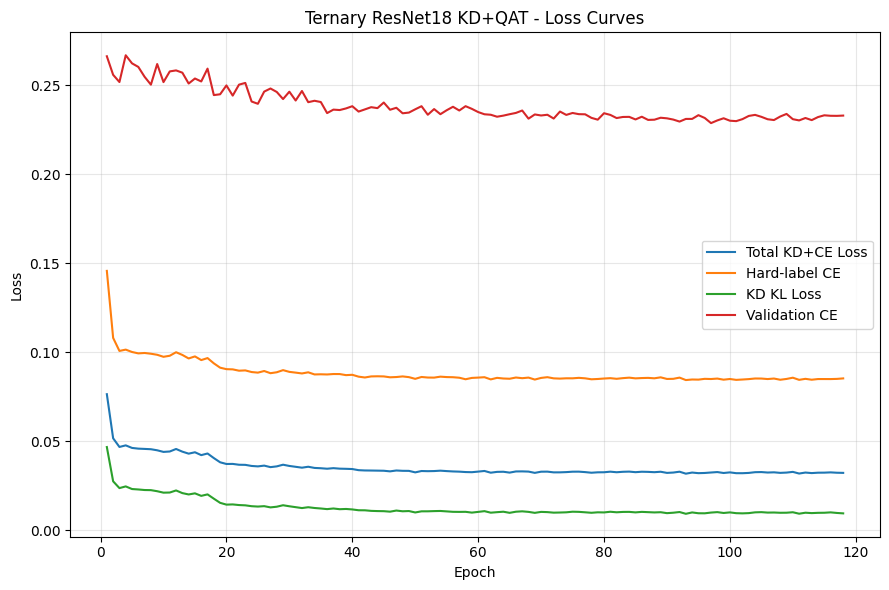

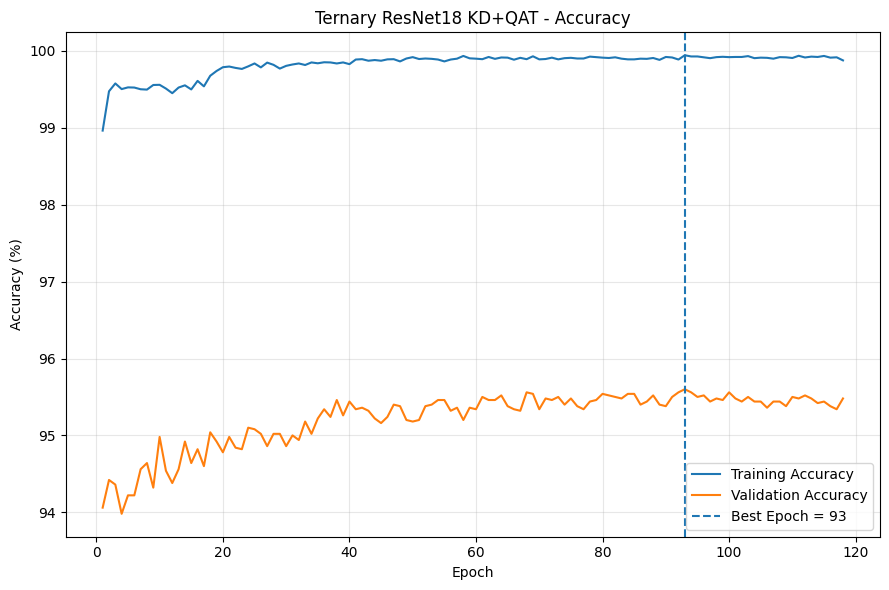

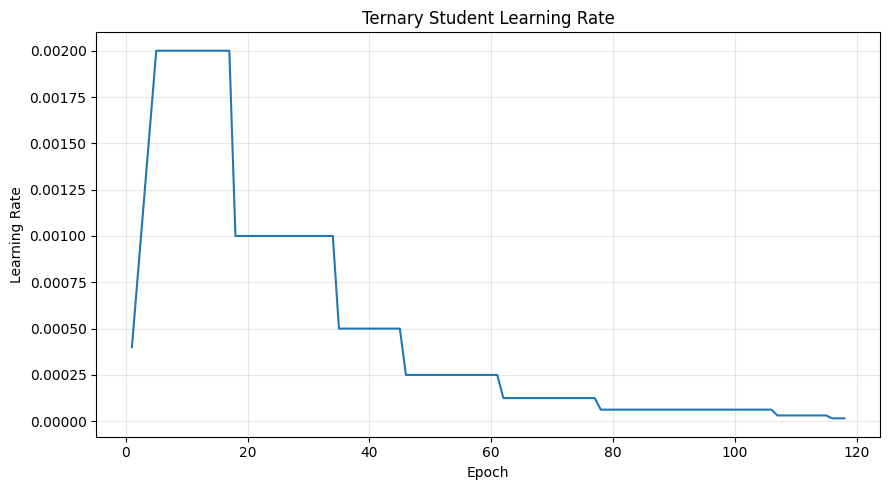

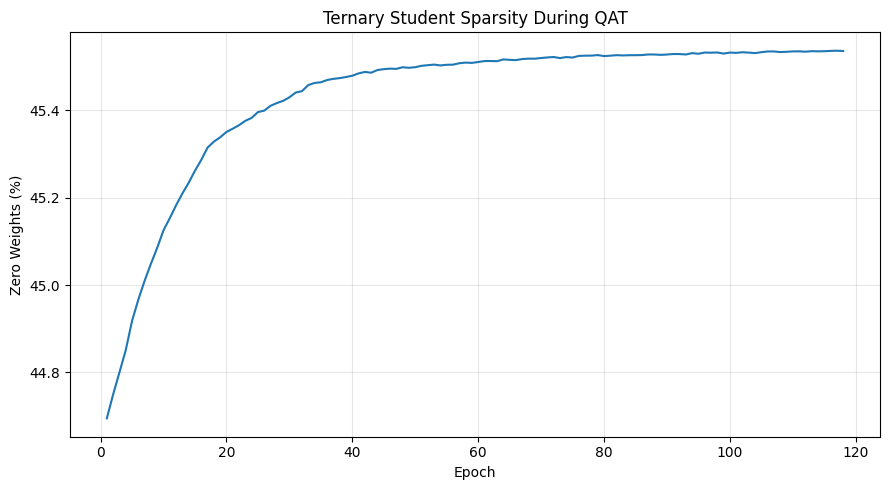

In [25]:
# ============================================================
# CELL 13: Student training curves
# ============================================================

history_df = pd.read_csv(
    LOG_DIR /
    "training_history.csv"
)


# ------------------------------------------------------------
# Loss components
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    history_df["epoch"],
    history_df[
        "train_total_loss"
    ],
    label="Total KD+CE Loss"
)


plt.plot(
    history_df["epoch"],
    history_df[
        "train_ce_loss"
    ],
    label="Hard-label CE"
)


plt.plot(
    history_df["epoch"],
    history_df[
        "train_kd_loss"
    ],
    label="KD KL Loss"
)


plt.plot(
    history_df["epoch"],
    history_df[
        "val_loss"
    ],
    label="Validation CE"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Ternary ResNet18 KD+QAT - Loss Curves"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "student_loss_curves.png",
    dpi=250,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    history_df["epoch"],
    history_df[
        "train_accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    history_df["epoch"],
    history_df[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Ternary ResNet18 KD+QAT - Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "student_accuracy_curves.png",
    dpi=250,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# Learning rate
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    history_df["epoch"],
    history_df[
        "learning_rate"
    ]
)


plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "Ternary Student Learning Rate"
)

plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "student_learning_rate.png",
    dpi=250,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# Sparsity
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    history_df["epoch"],
    history_df[
        "sparsity_percent"
    ]
)


plt.xlabel("Epoch")
plt.ylabel("Zero Weights (%)")

plt.title(
    "Ternary Student Sparsity During QAT"
)

plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "student_sparsity_curve.png",
    dpi=250,
    bbox_inches="tight"
)


plt.show()

In [26]:
# ============================================================
# CELL 14: Reload best KD+QAT student
# ============================================================

best_checkpoint = torch.load(
    BEST_STUDENT_PATH,
    map_location="cpu",
    weights_only=False
)


best_student = (
    build_cifar_resnet18(
        num_classes=10
    )
)


convert_internal_layers_to_ternary(
    best_student
)


best_student.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


best_student = best_student.to(
    DEVICE
)

best_student.eval()


restored_val_metrics = (
    evaluate_student(
        best_student,
        val_loader,
        DEVICE
    )
)


print(
    "Checkpoint epoch:",
    best_checkpoint["epoch"]
)

print(
    "Stored validation accuracy:",
    f"{best_checkpoint['best_val_accuracy']:.2f}%"
)

print(
    "Restored validation accuracy:",
    f"{restored_val_metrics['accuracy']:.2f}%"
)


restored_stats = (
    calculate_ternary_statistics(
        best_student
    )
)


print(
    "\nRestored sparsity:",
    f"{restored_stats['sparsity_percent']:.2f}%"
)

print(
    "All ternary codes valid:",
    restored_stats[
        "all_codes_valid"
    ]
)

Checkpoint epoch: 93
Stored validation accuracy: 95.60%
Restored validation accuracy: 95.60%

Restored sparsity: 45.53%
All ternary codes valid: True


In [27]:
# ============================================================
# CELL 15: FINAL official CIFAR-10 evaluation
# ============================================================

clean_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=eval_transform
)


test_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=False,
    download=False,
    transform=eval_transform
)


clean_train_loader = DataLoader(

    clean_train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


clean_train_metrics = (
    evaluate_student(
        best_student,
        clean_train_loader,
        DEVICE
    )
)


test_metrics = (
    evaluate_student(
        best_student,
        test_loader,
        DEVICE
    )
)


generalization_gap = (
    clean_train_metrics[
        "accuracy"
    ]
    -
    test_metrics[
        "accuracy"
    ]
)


print("=" * 72)
print("FINAL TERNARY KD+QAT STUDENT")
print("=" * 72)

print(
    "Clean train accuracy :",
    f"{clean_train_metrics['accuracy']:.2f}%"
)

print(
    "Validation accuracy  :",
    f"{restored_val_metrics['accuracy']:.2f}%"
)

print(
    "Official test accuracy:",
    f"{test_metrics['accuracy']:.2f}%"
)

print(
    "Train-test gap       :",
    f"{generalization_gap:.2f} pp"
)

print(
    "Ternary sparsity     :",
    f"{restored_stats['sparsity_percent']:.2f}%"
)

FINAL TERNARY KD+QAT STUDENT
Clean train accuracy : 99.56%
Validation accuracy  : 95.60%
Official test accuracy: 95.32%
Train-test gap       : 4.24 pp
Ternary sparsity     : 45.53%


In [28]:
# ============================================================
# CELL 16: Export genuinely compact ternary checkpoint
# ============================================================

COMPACT_PATH = (
    CHECKPOINT_DIR /
    "student_ternary_compressed.pth"
)


def pack_ternary_codes(
    codes
):
    """
    Map:
        -1 -> 0
         0 -> 1
        +1 -> 2

    Pack four 2-bit values into one byte.
    """

    flat = (
        codes.detach()
        .cpu()
        .reshape(-1)
        .to(torch.int16)
    )


    mapped = (
        flat + 1
    ).to(
        torch.uint8
    )


    assert torch.all(
        mapped <= 2
    )


    original_numel = (
        mapped.numel()
    )


    padding = (
        -original_numel
    ) % 4


    if padding:

        mapped = torch.cat([

            mapped,

            torch.ones(
                padding,
                dtype=torch.uint8
            )
        ])


    mapped = mapped.view(
        -1,
        4
    ).to(
        torch.int64
    )


    packed = (

        mapped[:, 0]

        |

        (
            mapped[:, 1]
            << 2
        )

        |

        (
            mapped[:, 2]
            << 4
        )

        |

        (
            mapped[:, 3]
            << 6
        )
    ).to(
        torch.uint8
    )


    return (
        packed,
        original_numel
    )



compact_layers = {}

ternary_weight_keys = set()


for name, module in (
    best_student.named_modules()
):

    if isinstance(
        module,
        (
            TernaryConv2d,
            TernaryLinear
        )
    ):

        (
            quantized,
            codes,
            alpha,
            delta
        ) = (
            module.get_quantized_weight()
        )


        packed, numel = (
            pack_ternary_codes(
                codes
            )
        )


        compact_layers[name] = {

            "packed_codes":
                packed,

            "numel":
                int(numel),

            "shape":
                list(
                    codes.shape
                ),

            "alpha":
                alpha.squeeze()
                .cpu()
                .to(
                    torch.float32
                ),

            "delta_factor":
                DELTA_FACTOR
        }


        ternary_weight_keys.add(
            f"{name}.weight"
        )


# ------------------------------------------------------------
# Preserve only non-ternary tensors in normal precision
# ------------------------------------------------------------

full_state = (
    best_student.state_dict()
)


fp32_state = {

    key:
        value.detach().cpu()

    for key, value
    in full_state.items()

    if key not in
    ternary_weight_keys
}


compact_checkpoint = {

    "format":
        "ATDL_PACKED_TERNARY_V1",

    "architecture":
        "ResNet18",

    "dataset":
        "CIFAR-10",

    "ternary_encoding":
        "2-bit packed",

    "code_mapping":
        {
            "-1": 0,
            "0": 1,
            "+1": 2
        },

    "delta_factor":
        DELTA_FACTOR,

    "temperature":
        TEMPERATURE,

    "kd_lambda":
        KD_LAMBDA,

    "fp32_exceptions":
        [
            "conv1",
            "fc",
            "BatchNorm parameters/buffers"
        ],

    "ternary_layers":
        compact_layers,

    "fp32_state":
        fp32_state,

    "test_accuracy":
        float(
            test_metrics[
                "accuracy"
            ]
        ),

    "validation_accuracy":
        float(
            restored_val_metrics[
                "accuracy"
            ]
        )
}


torch.save(
    compact_checkpoint,
    COMPACT_PATH
)


compact_size_bytes = (
    COMPACT_PATH.stat().st_size
)


compact_size_mib = (
    compact_size_bytes /
    (1024 ** 2)
)


training_checkpoint_size = (
    BEST_STUDENT_PATH.stat().st_size
)


baseline_checkpoint_size = (
    BASELINE_CHECKPOINT_PATH.stat().st_size
)


actual_compression_ratio = (

    baseline_checkpoint_size /
    compact_size_bytes
)


print(
    "Compact ternary checkpoint:"
)

print(
    COMPACT_PATH
)

print(
    "\nActual compact size:",
    f"{compact_size_mib:.2f} MiB"
)

print(
    "FP32 baseline checkpoint:",
    f"{baseline_checkpoint_size / (1024**2):.2f} MiB"
)

print(
    "Actual compression ratio vs baseline:",
    f"{actual_compression_ratio:.2f}x"
)

Compact ternary checkpoint:
/kaggle/working/ATDL_Ternary_KD_QAT_Student/checkpoints/student_ternary_compressed.pth

Actual compact size: 2.82 MiB
FP32 baseline checkpoint: 42.70 MiB
Actual compression ratio vs baseline: 15.13x


In [29]:
# ============================================================
# CELL 17: Verify compact ternary checkpoint
# ============================================================

def unpack_ternary_codes(
    packed,
    numel
):

    p = (
        packed
        .cpu()
        .to(
            torch.int64
        )
    )


    unpacked = torch.stack([

        p & 0b11,

        (
            p >> 2
        )
        & 0b11,

        (
            p >> 4
        )
        & 0b11,

        (
            p >> 6
        )
        & 0b11

    ], dim=1).reshape(-1)


    unpacked = (
        unpacked[:numel]
    )


    if torch.any(
        unpacked > 2
    ):

        raise ValueError(
            "Invalid 2-bit ternary code detected."
        )


    codes = (
        unpacked.to(
            torch.int8
        )
        -
        1
    )


    return codes



loaded_compact = torch.load(
    COMPACT_PATH,
    map_location="cpu",
    weights_only=False
)


verification_layers = []

total_ternary = 0
total_zero = 0

all_valid = True


for (
    layer_name,
    info
) in loaded_compact[
    "ternary_layers"
].items():


    codes = (
        unpack_ternary_codes(

            info[
                "packed_codes"
            ],

            info[
                "numel"
            ]
        )
    )


    codes = codes.reshape(
        info[
            "shape"
        ]
    )


    valid_codes = torch.all(

        (codes == -1)

        |

        (codes == 0)

        |

        (codes == 1)

    ).item()


    alpha = info[
        "alpha"
    ]


    alpha_shape = [

        alpha.numel()

    ] + [

        1
        for _ in range(
            len(
                info["shape"]
            )
            -
            1
        )
    ]


    reconstructed = (

        codes.to(
            torch.float32
        )

        *

        alpha.reshape(
            alpha_shape
        )
    )


    layer_zero = (
        codes == 0
    ).sum().item()


    layer_total = (
        codes.numel()
    )


    total_zero += (
        layer_zero
    )

    total_ternary += (
        layer_total
    )


    verification_layers.append({

        "layer":
            layer_name,

        "weights":
            layer_total,

        "zeros":
            layer_zero,

        "sparsity_percent":
            100.0 *
            layer_zero /
            layer_total,

        "valid_codes":
            bool(
                valid_codes
            )
    })


    all_valid = (
        all_valid
        and
        valid_codes
    )


compact_sparsity = (

    100.0 *
    total_zero /
    total_ternary
)


verification = {

    "checkpoint":
        str(
            COMPACT_PATH
        ),

    "ternary_weights":
        total_ternary,

    "zero_weights":
        total_zero,

    "sparsity_percent":
        compact_sparsity,

    "all_ternary_codes_valid":
        bool(
            all_valid
        ),

    "verification":
        (
            "PASS"
            if all_valid
            else "FAIL"
        ),

    "layers":
        verification_layers
}


with open(
    RESULT_DIR /
    "ternary_verification.json",
    "w"
) as f:

    json.dump(
        verification,
        f,
        indent=4
    )


print(
    "Verification:",
    verification[
        "verification"
    ]
)

print(
    "Ternary weights:",
    f"{total_ternary:,}"
)

print(
    "Zero weights:",
    f"{total_zero:,}"
)

print(
    "Sparsity:",
    f"{compact_sparsity:.2f}%"
)


assert all_valid


print(
    "\nPASS: compact checkpoint contains "
    "only valid ternary codes."
)

Verification: PASS
Ternary weights: 11,157,504
Zero weights: 5,079,809
Sparsity: 45.53%

PASS: compact checkpoint contains only valid ternary codes.


In [30]:
# ============================================================
# CELL 18: Save final student metrics and compression info
# ============================================================

student_total_parameters = sum(
    p.numel()
    for p in best_student.parameters()
)


ternary_parameter_count = (
    total_ternary
)


fp32_parameter_count = (

    student_total_parameters
    -
    ternary_parameter_count
)


theoretical_ternary_bits = (

    ternary_parameter_count
    *
    2
)


# Alpha storage
alpha_values = sum(

    info[
        "alpha"
    ].numel()

    for info in compact_layers.values()
)


alpha_bits = (
    alpha_values
    *
    32
)


# FP32/non-ternary state raw bytes
fp32_state_bytes = sum(

    tensor.numel()
    *
    tensor.element_size()

    for tensor
    in fp32_state.values()
)


packed_weight_bytes = sum(

    info[
        "packed_codes"
    ].numel()

    for info
    in compact_layers.values()
)


theoretical_compact_bytes = (

    packed_weight_bytes

    +

    alpha_values * 4

    +

    fp32_state_bytes
)


baseline_raw_fp32_bytes = (

    student_total_parameters
    *
    4
)


theoretical_compression_ratio = (

    baseline_raw_fp32_bytes
    /
    theoretical_compact_bytes
)


accuracy_gap_vs_teacher = (

    teacher_checkpoint.get(
        "best_val_accuracy",
        np.nan
    )
)


final_metrics = {

    "model":
        "ResNet18 Ternary + KD + QAT",

    "best_epoch":
        int(
            best_checkpoint[
                "epoch"
            ]
        ),

    "epochs_completed":
        int(
            epochs_completed
        ),

    "validation_accuracy":
        float(
            restored_val_metrics[
                "accuracy"
            ]
        ),

    "test_accuracy":
        float(
            test_metrics[
                "accuracy"
            ]
        ),

    "clean_training_accuracy":
        float(
            clean_train_metrics[
                "accuracy"
            ]
        ),

    "train_test_gap":
        float(
            generalization_gap
        ),

    "temperature":
        TEMPERATURE,

    "kd_lambda":
        KD_LAMBDA,

    "delta_factor":
        DELTA_FACTOR,

    "total_parameters":
        int(
            student_total_parameters
        ),

    "ternary_weight_count":
        int(
            ternary_parameter_count
        ),

    "fp32_parameter_count":
        int(
            fp32_parameter_count
        ),

    "zero_ternary_weights":
        int(
            total_zero
        ),

    "ternary_sparsity_percent":
        float(
            compact_sparsity
        ),

    "training_checkpoint_size_mib":
        float(
            training_checkpoint_size
            /
            (1024 ** 2)
        ),

    "compact_checkpoint_size_mib":
        float(
            compact_size_mib
        ),

    "actual_compression_ratio_vs_fp32_baseline":
        float(
            actual_compression_ratio
        ),

    "theoretical_compact_storage_bytes":
        int(
            theoretical_compact_bytes
        ),

    "theoretical_compression_ratio":
        float(
            theoretical_compression_ratio
        ),

    "fp32_exceptions":
        [
            "conv1",
            "fc"
        ]
}


with open(
    RESULT_DIR /
    "student_final_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )


compression_info = {

    "ternary_weights":
        int(
            ternary_parameter_count
        ),

    "ternary_bit_width":
        2,

    "packed_weight_bytes":
        int(
            packed_weight_bytes
        ),

    "alpha_values":
        int(
            alpha_values
        ),

    "alpha_storage_bytes":
        int(
            alpha_values * 4
        ),

    "non_ternary_state_bytes":
        int(
            fp32_state_bytes
        ),

    "theoretical_compact_bytes":
        int(
            theoretical_compact_bytes
        ),

    "actual_compact_checkpoint_bytes":
        int(
            compact_size_bytes
        ),

    "actual_compression_ratio_vs_baseline_checkpoint":
        float(
            actual_compression_ratio
        ),

    "theoretical_compression_ratio":
        float(
            theoretical_compression_ratio
        )
}


with open(
    RESULT_DIR /
    "compression_info.json",
    "w"
) as f:

    json.dump(
        compression_info,
        f,
        indent=4
    )


print(
    json.dumps(
        final_metrics,
        indent=4
    )
)

{
    "model": "ResNet18 Ternary + KD + QAT",
    "best_epoch": 93,
    "epochs_completed": 118,
    "validation_accuracy": 95.6,
    "test_accuracy": 95.32,
    "clean_training_accuracy": 99.56,
    "train_test_gap": 4.240000000000009,
    "temperature": 4.0,
    "kd_lambda": 0.7,
    "delta_factor": 0.7,
    "total_parameters": 11173962,
    "ternary_weight_count": 11157504,
    "fp32_parameter_count": 16458,
    "zero_ternary_weights": 5079809,
    "ternary_sparsity_percent": 45.528184439817366,
    "training_checkpoint_size_mib": 42.69953441619873,
    "compact_checkpoint_size_mib": 2.8211803436279297,
    "actual_compression_ratio_vs_fp32_baseline": 15.134954374620971,
    "theoretical_compact_storage_bytes": 2912712,
    "theoretical_compression_ratio": 15.34509694058321,
    "fp32_exceptions": [
        "conv1",
        "fc"
    ]
}


In [31]:
# ============================================================
# CELL 19: Generate standalone ternary verification script
# ============================================================

verification_script = r'''
import sys
import torch


def unpack_ternary_codes(packed, numel):

    p = packed.to(torch.int64)

    values = torch.stack([
        p & 0b11,
        (p >> 2) & 0b11,
        (p >> 4) & 0b11,
        (p >> 6) & 0b11
    ], dim=1).reshape(-1)

    values = values[:numel]

    if torch.any(values > 2):
        raise ValueError(
            "Invalid 2-bit ternary code detected."
        )

    return (
        values.to(torch.int8)
        -
        1
    )


def verify(path):

    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    total = 0
    zero = 0
    valid = True

    print(
        "Checkpoint format:",
        checkpoint.get("format")
    )

    print()

    for name, info in checkpoint[
        "ternary_layers"
    ].items():

        codes = unpack_ternary_codes(
            info["packed_codes"],
            info["numel"]
        )

        codes = codes.reshape(
            info["shape"]
        )

        layer_valid = torch.all(
            (codes == -1)
            |
            (codes == 0)
            |
            (codes == 1)
        ).item()

        zeros = (
            codes == 0
        ).sum().item()

        count = codes.numel()

        total += count
        zero += zeros

        valid = valid and layer_valid

        print(
            f"{name:30s} "
            f"weights={count:10d} "
            f"sparsity={100*zeros/count:6.2f}% "
            f"valid={layer_valid}"
        )


    sparsity = (
        100.0 *
        zero /
        total
    )

    print("\n" + "=" * 70)

    print(
        "Total ternary weights:",
        total
    )

    print(
        "Zero weights:",
        zero
    )

    print(
        f"Sparsity: {sparsity:.2f}%"
    )

    print(
        "TERNARY VERIFICATION:",
        "PASS" if valid else "FAIL"
    )

    return valid


if __name__ == "__main__":

    if len(sys.argv) != 2:

        print(
            "Usage: python "
            "verify_ternary_checkpoint.py "
            "<student_ternary_compressed.pth>"
        )

        sys.exit(1)

    success = verify(
        sys.argv[1]
    )

    sys.exit(
        0 if success else 2
    )
'''


verification_script_path = (
    SCRIPT_DIR /
    "verify_ternary_checkpoint.py"
)


with open(
    verification_script_path,
    "w"
) as f:

    f.write(
        verification_script
    )


print(
    "Standalone verification script saved:"
)

print(
    verification_script_path
)

Standalone verification script saved:
/kaggle/working/ATDL_Ternary_KD_QAT_Student/scripts/verify_ternary_checkpoint.py


In [34]:
# ============================================================
# CELL 20: Create final Notebook 3 ZIP
# ============================================================

ZIP_BASE = (
    KAGGLE_WORKING_DIR /
    "ATDL_Ternary_KD_QAT_Student"
)


zip_path = shutil.make_archive(

    base_name=str(
        ZIP_BASE
    ),

    format="zip",

    root_dir=str(
        KAGGLE_WORKING_DIR
    ),

    base_dir=
        PROJECT_DIR.name
)


zip_size_mib = (

    os.path.getsize(
        zip_path
    )

    /
    (1024 ** 2)
)


print("=" * 76)
print("NOTEBOOK 3 EXPORT COMPLETE")
print("=" * 76)

print("\nZIP:")
print(zip_path)

print(
    f"\nZIP size: "
    f"{zip_size_mib:.2f} MiB"
)

print(
    "\nTraining checkpoint:"
)

print(
    BEST_STUDENT_PATH
)

print(
    "\nCompact checkpoint:"
)

print(
    COMPACT_PATH
)

print(
    "\nFinal validation accuracy:",
    f"{restored_val_metrics['accuracy']:.2f}%"
)

print(
    "Final test accuracy:",
    f"{test_metrics['accuracy']:.2f}%"
)

print(
    "Ternary sparsity:",
    f"{compact_sparsity:.2f}%"
)

print(
    "Compact checkpoint size:",
    f"{compact_size_mib:.2f} MiB"
)

print(
    "Actual compression ratio:",
    f"{actual_compression_ratio:.2f}x"
)

print(
    "\nNotebook 3 outputs ready."
)

NOTEBOOK 3 EXPORT COMPLETE

ZIP:
/kaggle/working/ATDL_Ternary_KD_QAT_Student.zip

ZIP size: 42.22 MiB

Training checkpoint:
/kaggle/working/ATDL_Ternary_KD_QAT_Student/checkpoints/student_training.pth

Compact checkpoint:
/kaggle/working/ATDL_Ternary_KD_QAT_Student/checkpoints/student_ternary_compressed.pth

Final validation accuracy: 95.60%
Final test accuracy: 95.32%
Ternary sparsity: 45.53%
Compact checkpoint size: 2.82 MiB
Actual compression ratio: 15.13x

Notebook 3 outputs ready.


In [33]:
# ============================================================
# COMPACT CHECKPOINT RELOAD + INFERENCE VERIFICATION
# ============================================================

def load_model_from_compact_checkpoint(
    compact_path,
    device
):
    """
    Reconstruct a usable ternary ResNet18 directly from the
    packed 2-bit checkpoint.

    No latent FP32 training weights are loaded.
    """

    compact = torch.load(
        compact_path,
        map_location="cpu",
        weights_only=False
    )

    # --------------------------------------------------------
    # Build the same ternary architecture
    # --------------------------------------------------------

    model = build_cifar_resnet18(
        num_classes=10
    )

    convert_internal_layers_to_ternary(
        model
    )


    # --------------------------------------------------------
    # Restore FP32 exceptions / BN parameters / buffers
    # --------------------------------------------------------

    current_state = model.state_dict()

    for key, value in compact[
        "fp32_state"
    ].items():

        current_state[key] = value


    model.load_state_dict(
        current_state,
        strict=False
    )


    # --------------------------------------------------------
    # Restore ternary weights from packed 2-bit codes
    # --------------------------------------------------------

    named_modules = dict(
        model.named_modules()
    )


    for layer_name, info in compact[
        "ternary_layers"
    ].items():

        module = named_modules[
            layer_name
        ]


        # Decode packed 2-bit codes
        codes = unpack_ternary_codes(

            info[
                "packed_codes"
            ],

            info[
                "numel"
            ]
        )


        codes = codes.reshape(
            info[
                "shape"
            ]
        )


        alpha = info[
            "alpha"
        ].to(
            torch.float32
        )


        # Shape alpha as:
        # [out_channels, 1, 1, 1]
        # for Conv2d
        #
        # or
        # [out_features, 1]
        # for Linear

        alpha_shape = [

            alpha.numel()

        ] + [

            1
            for _ in range(
                len(
                    info[
                        "shape"
                    ]
                )
                - 1
            )
        ]


        reconstructed_weight = (

            codes.to(
                torch.float32
            )

            *

            alpha.reshape(
                alpha_shape
            )
        )


        # ----------------------------------------------------
        # Verify reconstructed values
        # ----------------------------------------------------

        expected_positive = (
            alpha.reshape(
                alpha_shape
            )
        )

        valid = torch.all(

            torch.isclose(
                reconstructed_weight,
                torch.zeros_like(
                    reconstructed_weight
                )
            )

            |

            torch.isclose(
                reconstructed_weight,
                expected_positive.expand_as(
                    reconstructed_weight
                )
            )

            |

            torch.isclose(
                reconstructed_weight,
                -expected_positive.expand_as(
                    reconstructed_weight
                )
            )
        )


        if not valid:

            raise ValueError(
                f"Invalid ternary reconstruction "
                f"in layer: {layer_name}"
            )


        # Copy reconstructed ternary weight into layer
        with torch.no_grad():

            module.weight.copy_(
                reconstructed_weight
            )


    model = model.to(
        device
    )

    model.eval()

    return model



# ============================================================
# Load ONLY the compact checkpoint
# ============================================================

compact_student = (
    load_model_from_compact_checkpoint(

        COMPACT_PATH,

        DEVICE
    )
)


print(
    "Compact checkpoint reconstructed successfully."
)


# ============================================================
# Validate ternary structure again
# ============================================================

compact_reload_stats = (
    calculate_ternary_statistics(
        compact_student
    )
)


print(
    "\nTernary verification after reload:"
)

print(
    "All codes valid :",
    compact_reload_stats[
        "all_codes_valid"
    ]
)

print(
    "Sparsity        :",
    f"{compact_reload_stats['sparsity_percent']:.2f}%"
)


assert compact_reload_stats[
    "all_codes_valid"
]


# ============================================================
# Validation accuracy from compact-only reconstruction
# ============================================================

compact_val_metrics = (
    evaluate_student(

        compact_student,

        val_loader,

        DEVICE
    )
)


# ============================================================
# Test accuracy from compact-only reconstruction
# ============================================================

compact_test_metrics = (
    evaluate_student(

        compact_student,

        test_loader,

        DEVICE
    )
)


print("\n" + "=" * 72)

print(
    "COMPACT CHECKPOINT INFERENCE VERIFICATION"
)

print("=" * 72)


print(
    f"Original best student validation accuracy : "
    f"{restored_val_metrics['accuracy']:.4f}%"
)

print(
    f"Compact-reloaded validation accuracy       : "
    f"{compact_val_metrics['accuracy']:.4f}%"
)


print(
    f"\nOriginal best student test accuracy       : "
    f"{test_metrics['accuracy']:.4f}%"
)

print(
    f"Compact-reloaded test accuracy             : "
    f"{compact_test_metrics['accuracy']:.4f}%"
)


validation_difference = abs(

    compact_val_metrics[
        "accuracy"
    ]

    -

    restored_val_metrics[
        "accuracy"
    ]
)


test_difference = abs(

    compact_test_metrics[
        "accuracy"
    ]

    -

    test_metrics[
        "accuracy"
    ]
)


print(
    f"\nValidation accuracy difference : "
    f"{validation_difference:.6f} pp"
)

print(
    f"Test accuracy difference       : "
    f"{test_difference:.6f} pp"
)


# ============================================================
# Save verification result
# ============================================================

compact_reload_verification = {

    "compact_checkpoint":
        str(
            COMPACT_PATH
        ),

    "reconstruction":
        "PASS",

    "ternary_constraint":
        "PASS",

    "sparsity_percent":
        float(
            compact_reload_stats[
                "sparsity_percent"
            ]
        ),

    "original_validation_accuracy":
        float(
            restored_val_metrics[
                "accuracy"
            ]
        ),

    "compact_validation_accuracy":
        float(
            compact_val_metrics[
                "accuracy"
            ]
        ),

    "validation_accuracy_difference":
        float(
            validation_difference
        ),

    "original_test_accuracy":
        float(
            test_metrics[
                "accuracy"
            ]
        ),

    "compact_test_accuracy":
        float(
            compact_test_metrics[
                "accuracy"
            ]
        ),

    "test_accuracy_difference":
        float(
            test_difference
        )
}


with open(
    RESULT_DIR /
    "compact_reload_verification.json",
    "w"
) as f:

    json.dump(
        compact_reload_verification,
        f,
        indent=4
    )


print(
    "\nCompact checkpoint reload verification: PASS"
)

Compact checkpoint reconstructed successfully.

Ternary verification after reload:
All codes valid : True
Sparsity        : 45.53%

COMPACT CHECKPOINT INFERENCE VERIFICATION
Original best student validation accuracy : 95.6000%
Compact-reloaded validation accuracy       : 95.6000%

Original best student test accuracy       : 95.3200%
Compact-reloaded test accuracy             : 95.3200%

Validation accuracy difference : 0.000000 pp
Test accuracy difference       : 0.000000 pp

Compact checkpoint reload verification: PASS
